# Exploitation d'un run unique - EOLES multi-noeuds

Ce notebook construit et resout un scenario, puis affiche l'ensemble des graphiques qui ont besoin des donnees **horaires** d'un run (dispatch, prix spot, stockage, demande residuelle, interconnexions...).

Pour comparer plusieurs annees climatiques / scenarios entre eux a partir des CSV deja calcules par `run_batch.py`, voir `notebook_batch_comparison.ipynb` a la place.

**A adapter selon vos besoins** : la zone modelisee (`AREAS`), l'annee climatique (`YEARS_OF_INTEREST`), l'inclusion des reserves (`INCLUDE_RESERVE`), et la zone/l'heure affichee dans chaque graphique (`FOCUS_AREA`, `FOCUS_HOUR`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from utils_io import get_config
from utils_results import (
    check_vector_balance, compute_costs, compute_country_cost_summary, extract_capacity_duals,
    check_profit_dual_consistency,
)
from utils_plots import (
    plot_installed_power, plot_gene_per_tech,
    plot_elec_balance_week, plot_elec_residual_balance_week, plot_load_shift_week,
    plot_CH4_balance, plot_H2_balance,
    plot_residual_load_duration, plot_storage_state_year,
    plot_spot_price, plot_cost_breakdown, plot_cost_breakdown_per_mwh,
    plot_interconnection_utilization, plot_dual_vs_profit,
)
from modelEoles_multiN_v3_7 import ModelEOLES

pd.set_option("display.max_columns", None)

---
## 1. Construction et resolution du scenario

Meme logique que `example.py` / `run_batch.run_one()`. Modifiez `AREAS`, `INCLUDE_RESERVE` et `YEARS_OF_INTEREST` selon le cas que vous voulez explorer.

In [49]:
AREAS = ["FR", "UK", "IE"]              # countries to model; None = full set from links.csv
INCLUDE_RESERVE = True             # model FCR/FRR reserves (France by default)
YEARS_OF_INTEREST = [2044]         # climate year(s) to optimise over
FOCUS_AREA = "FR"                  # area shown in single-area charts below
OUTPUT_PATH = "outputs/notebook_single_run"

Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)
config = get_config("config/config_multi_nodes.json")

m = ModelEOLES(
    name="notebook_single_run",
    config=config,
    output_path=OUTPUT_PATH,
    include_reserve=INCLUDE_RESERVE,
    restricted_area=AREAS,
    years_of_interest=YEARS_OF_INTEREST,
    # detailed_countries=["FR"],    # default: only France gets DSM/reserves/hydro specifics
)
m.build_model()
status, termination = m.solve(solver_name="gurobi")
print(f"Solve status: {status} / {termination}")

m.extract_optimisation_results_linopy()
print(f"Total system cost: {m.system_social_cost:.1f} M-EUR/yr")

Solving EOLES model using gurobi
Barrier algorithm only (no crossover). Solution may not be basic.


Writing continuous variables.: 100%|██████████| 21/21 [00:00<00:00, 82.78it/s]


Set parameter Username
Set parameter LicenseID to value 2775158
Academic license - for non-commercial use only - expires 2027-02-04
Read LP format model from file C:\Users\hadri\AppData\Local\Temp\linopy-problem-h0vdis6a.lp
Reading time = 7.13 seconds
obj: 2549930 rows, 1874805 columns, 8429634 nonzeros
Set parameter Method to value 2
Set parameter Crossover to value 0
Set parameter NumericFocus to value 3
Set parameter BarConvTol to value 1e-08
Set parameter Presolve to value 2
Set parameter LogFile to value "outputs/notebook_single_run/logfile_notebook_single_run.txt"
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Method  2
Crossover  0
NumericFocus  3
Presolve  2

Optimize a model with 2549930 rows, 1874805 columns and 8429634 nonzeros (Min)
Model fin

c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn

Total system cost: 124244.1 M-EUR/yr


In [50]:
m.summary

,FR,UK,IE
total system cost [1e9€],1.242441e+02,1.242441e+02,124.244144
elec_demand_tot [TWh],5.167868e+02,5.179791e+02,43.971532
H2_demand_tot [TWh],4.629660e+01,5.630000e+01,19.200000
CH4_demand_tot [TWh],1.390975e+02,8.700000e+01,8.000000
elec_price_weighted_by_demand [€/MWh],8.093225e+01,7.581466e+01,77.180776
CH4_price_weighted_by_demand [€/MWh],9.590580e+01,9.590580e+01,95.905803
H2_price_weighted_by_demand [€/MWh],5.928059e+01,5.928059e+01,59.280592
load_shifted [TWh],2.500680e+01,0.000000e+00,0.000000
load_shifted [%],4.838901e+00,0.000000e+00,0.000000
attributed_cost [1e9€],5.706693e+01,6.830114e+01,16.592480


---
## 2. Garde-fou : equilibre offre/demande par vecteur

`check_vector_balance` recalcule independamment le bilan production/consommation pour chaque vecteur a partir de `hourly_balance` (+ le commerce annuel CH4/H2, cf. `trade_net_twh`).

- Pour l'electricite, `net_result` doit etre ~0 dans les deux sens (l'ecretement est deja suivi explicitement).
- Pour CH4/H2, l'adequation est une inegalite (offre >= demande) : un leger **surplus** (quelques % de la demande) est normal - c'est de l'ecretement implicite non trace, amplifie par la methode barrier sans crossover utilisee par le solveur. Seul un **deficit** (offre < demande), ou un surplus anormalement grand, est signale par un warning.

In [51]:
ch4_trade_net = (m.model.solution["gas annual import"] - m.model.solution["gas annual export"]).sum("year").to_pandas()
h2_trade_net = (m.model.solution["H2 annual import"] - m.model.solution["H2 annual export"]).sum("year").to_pandas()

check_vector_balance("elec", m.hourly_balance, m.countries,
                    str_elec=m.str_elec, elec_balance=m.elec_balance, elec_primary_prod=m.elec_primary_prod)

c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


[warn] elec balance mismatch in UK: -27784.031 MWh (-0.01% of demand)
[warn] elec balance mismatch in IE: -17396.672 MWh (-0.04% of demand)


,demand_for_elec,demand_for_CH4,demand_for_H2,exports,imports,curtailment,primary_prod,prod_from_CH4,prod_from_H2,losses_storage,net_result
FR,516.786768,3.443986,110.020774,30.191209,35.740309,14.696640,643.746788,8.155495,1.338346,13.841560,-8.705570e-11
UK,517.979146,49.489861,118.571922,116.327139,116.663617,13.342858,648.510407,9.254349,45.073820,3.819051,-2.778403e-02
IE,43.971532,64.995247,67.835679,86.484075,80.575197,11.604859,193.607395,0.853748,0.005599,0.167944,-1.739667e-02


In [52]:
check_vector_balance("CH4", m.hourly_balance, m.countries, trade_net_twh=ch4_trade_net)
check_vector_balance("H2", m.hourly_balance, m.countries, trade_net_twh=h2_trade_net)

,demand_for_h2,demand_for_elec,prod_from_electrolysis,prod_from_import,trade_net,storage_losses,net_result
FR,46.2966,2.230576,73.924058,0.0,-25.383234,-3.967315e-11,-1.364798e-02
UK,56.3000,75.123034,79.669660,0.0,51.753374,0.000000e+00,-5.790923e-12
IE,19.2000,0.009331,45.579471,0.0,-26.370140,0.000000e+00,-4.121148e-12


---
## 3. Capacite installee et generation par technologie

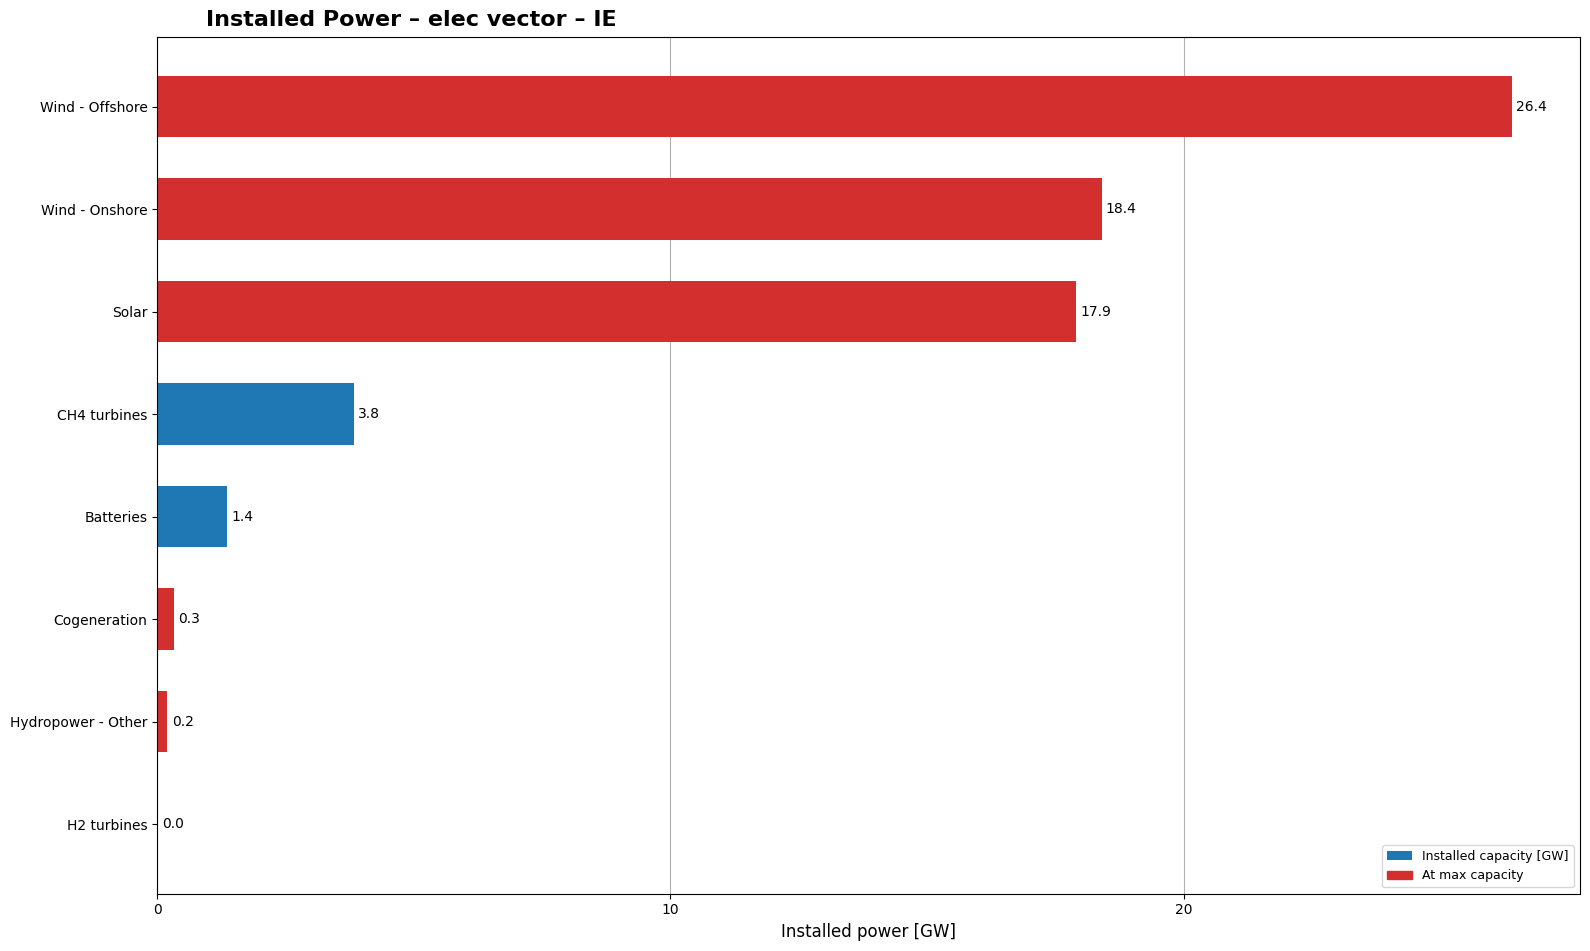

In [75]:
fig = plot_installed_power(m, m.installed_power, area="IE",
                           values=True, vector="elec", lang="EN")

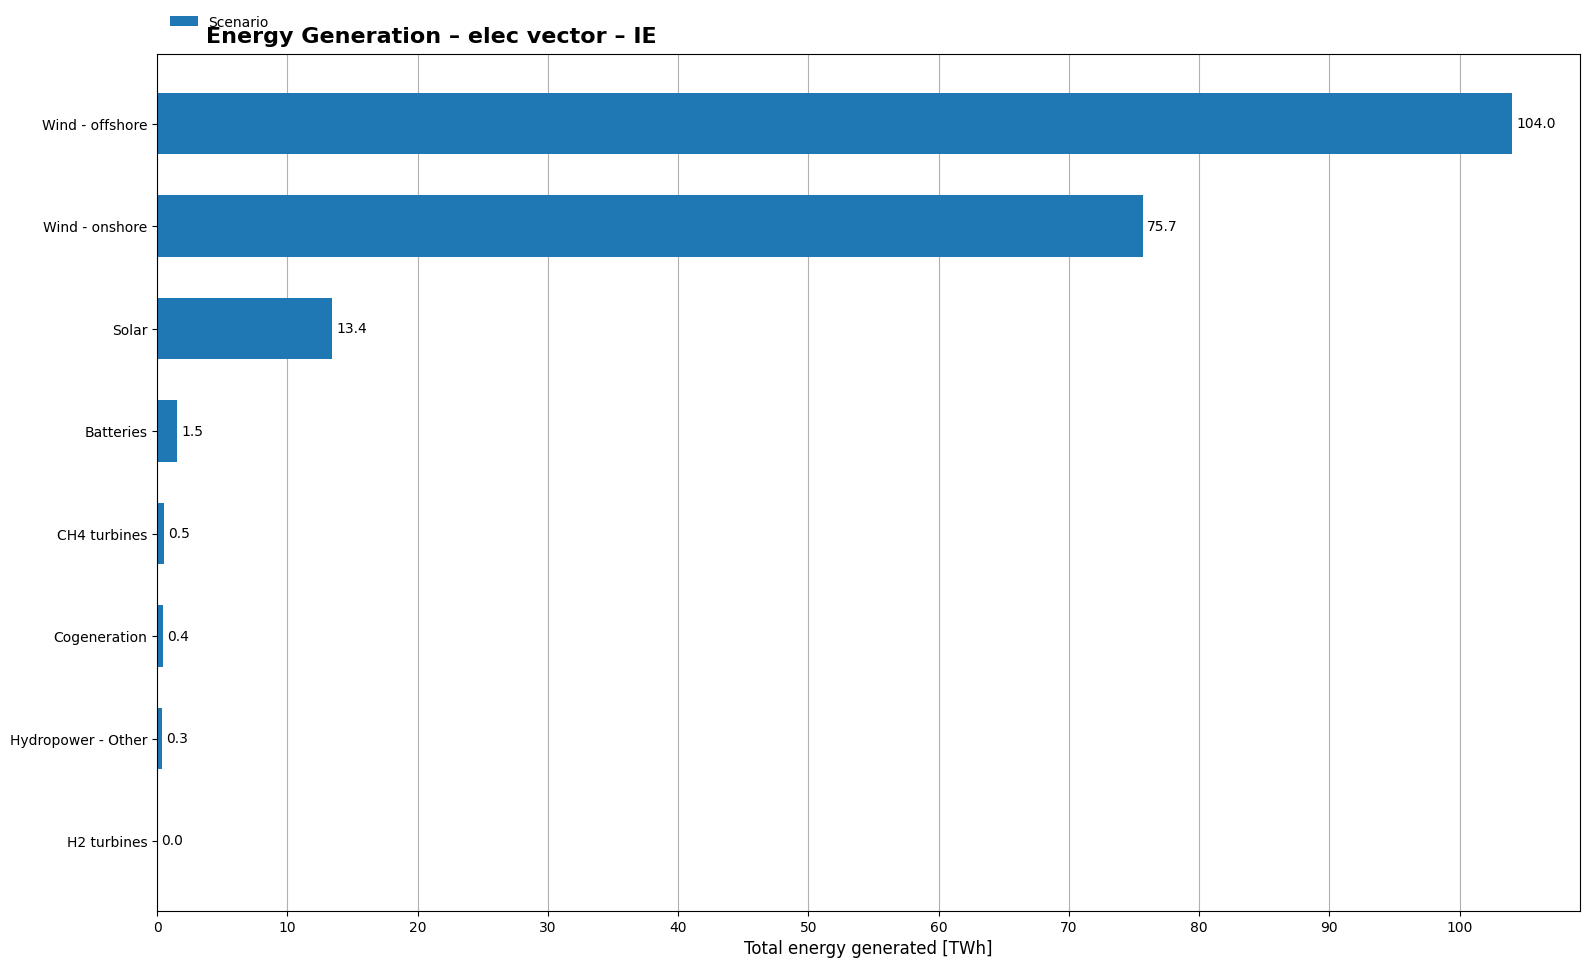

In [54]:
fig = plot_gene_per_tech(m, m.generation_per_technology, area="IE",
                         values=True, vector="elec", lang="EN")

---
## 4. Dispatch horaire electricite

Une semaine d'hiver, une d'ete, une d'entre-saison - a adapter (`hour` = heure de debut, `n_hours` = duree de la fenetre affichee).

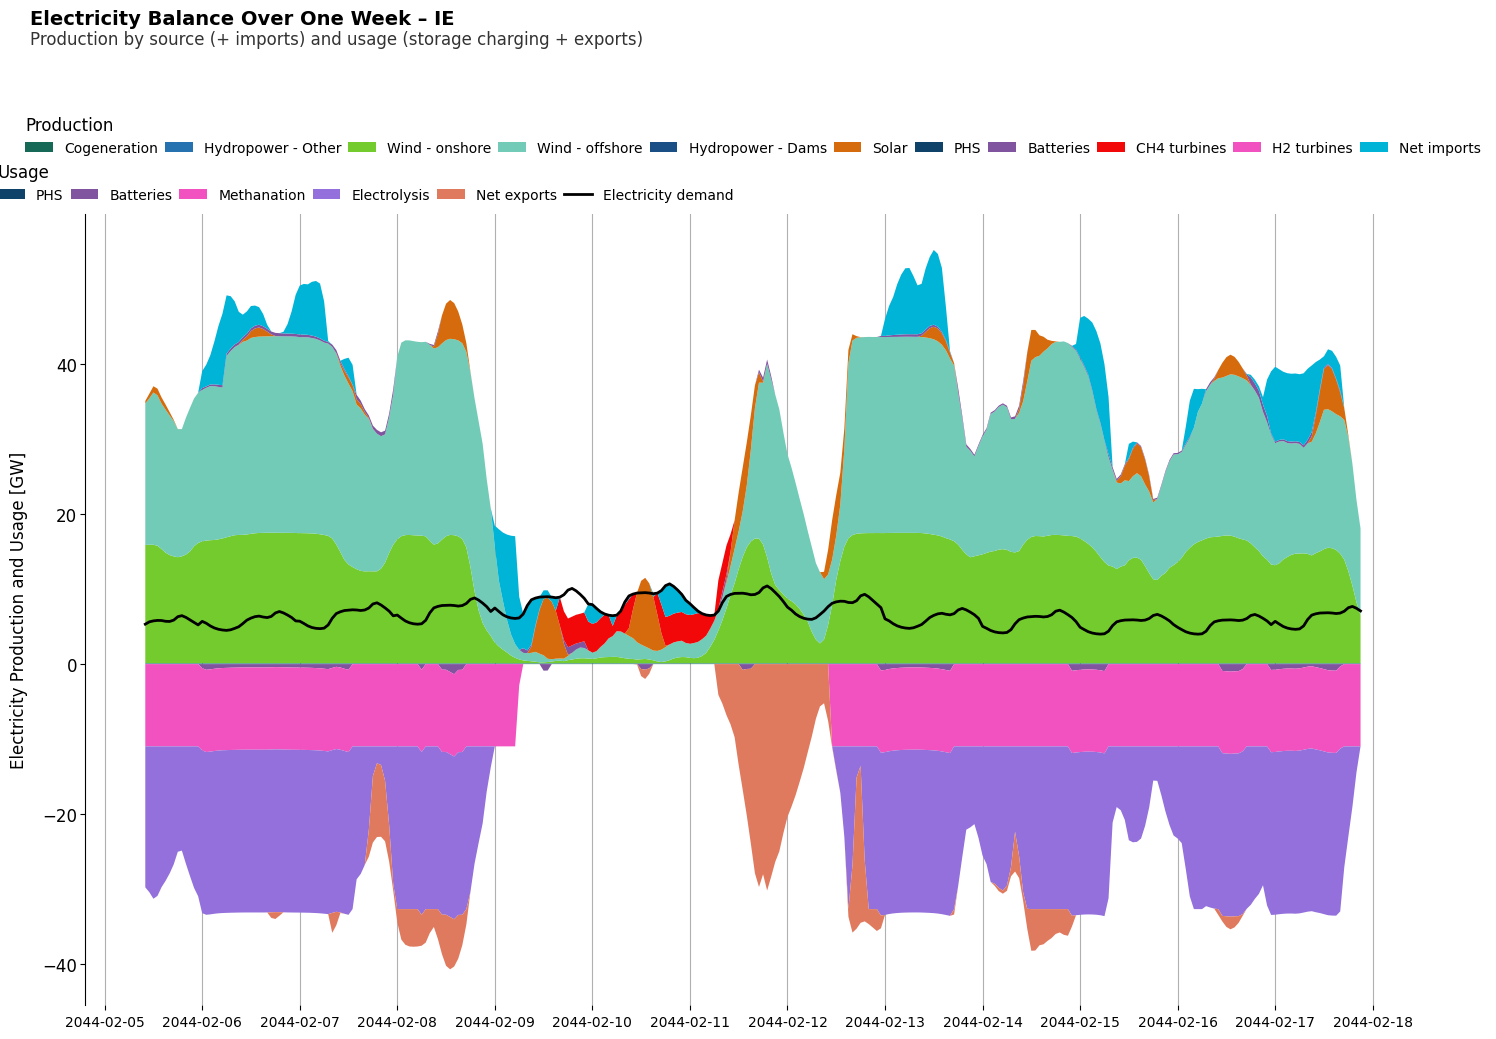

In [76]:
fig = plot_elec_balance_week(m, m.hourly_balance, m.installed_power,
                             hour=850, area="IE", lang="EN", n_hours = 300)   # winter

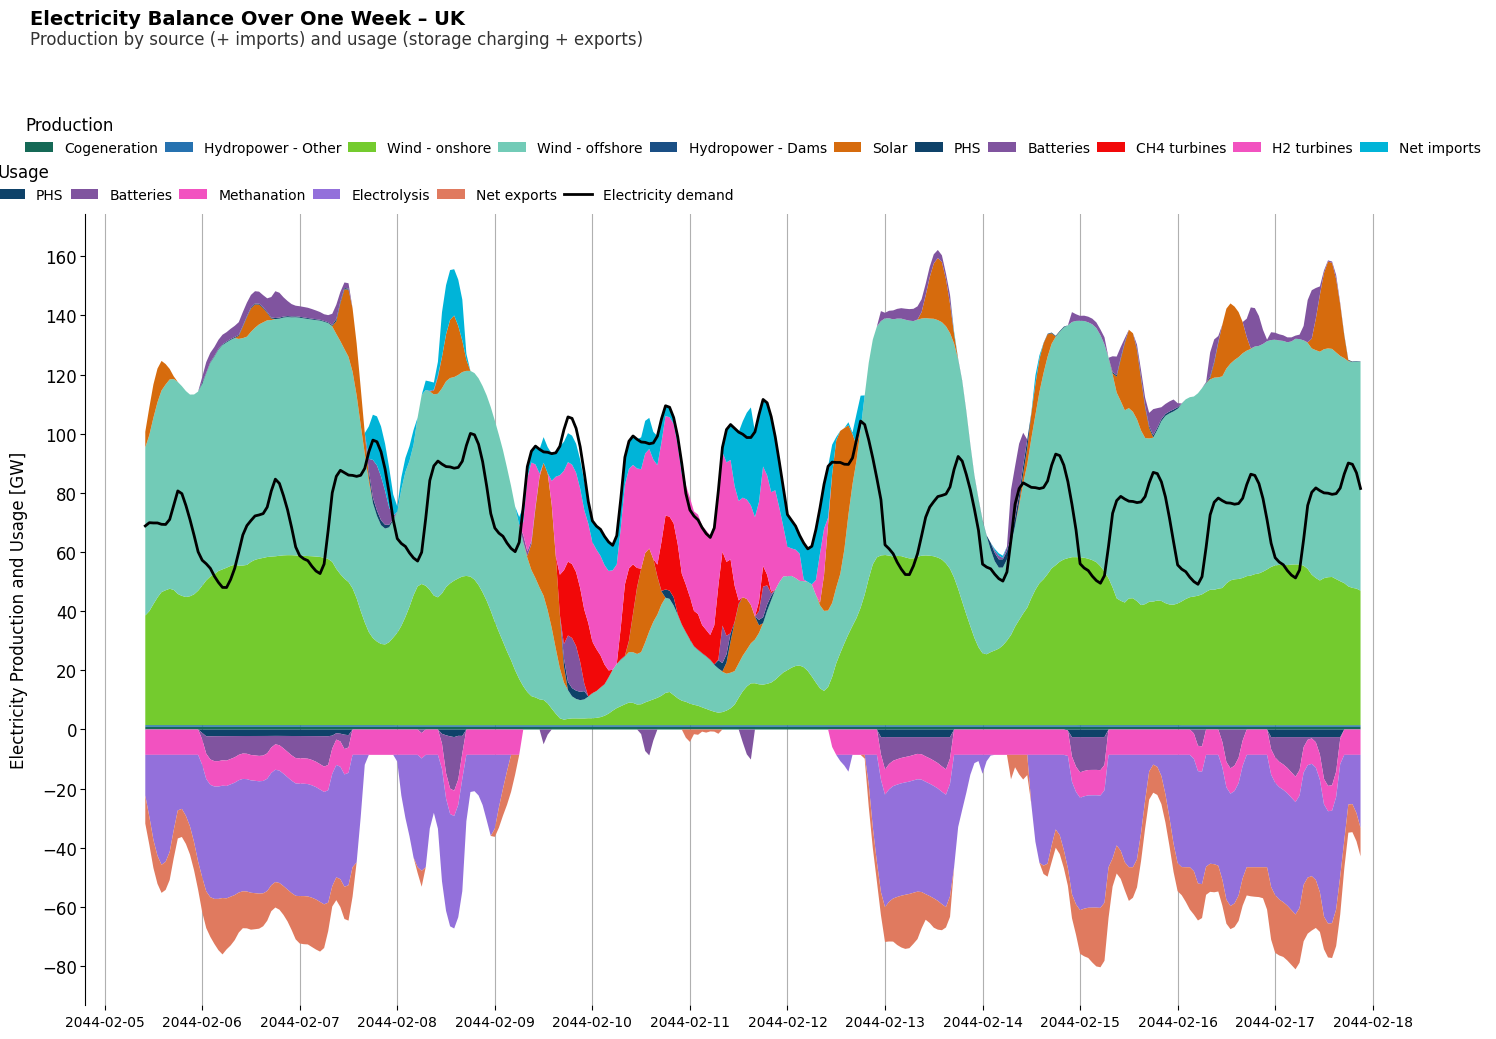

In [77]:
fig = plot_elec_balance_week(m, m.hourly_balance, m.installed_power,
                             hour=850, area="UK", lang="EN", n_hours = 300)   # winter

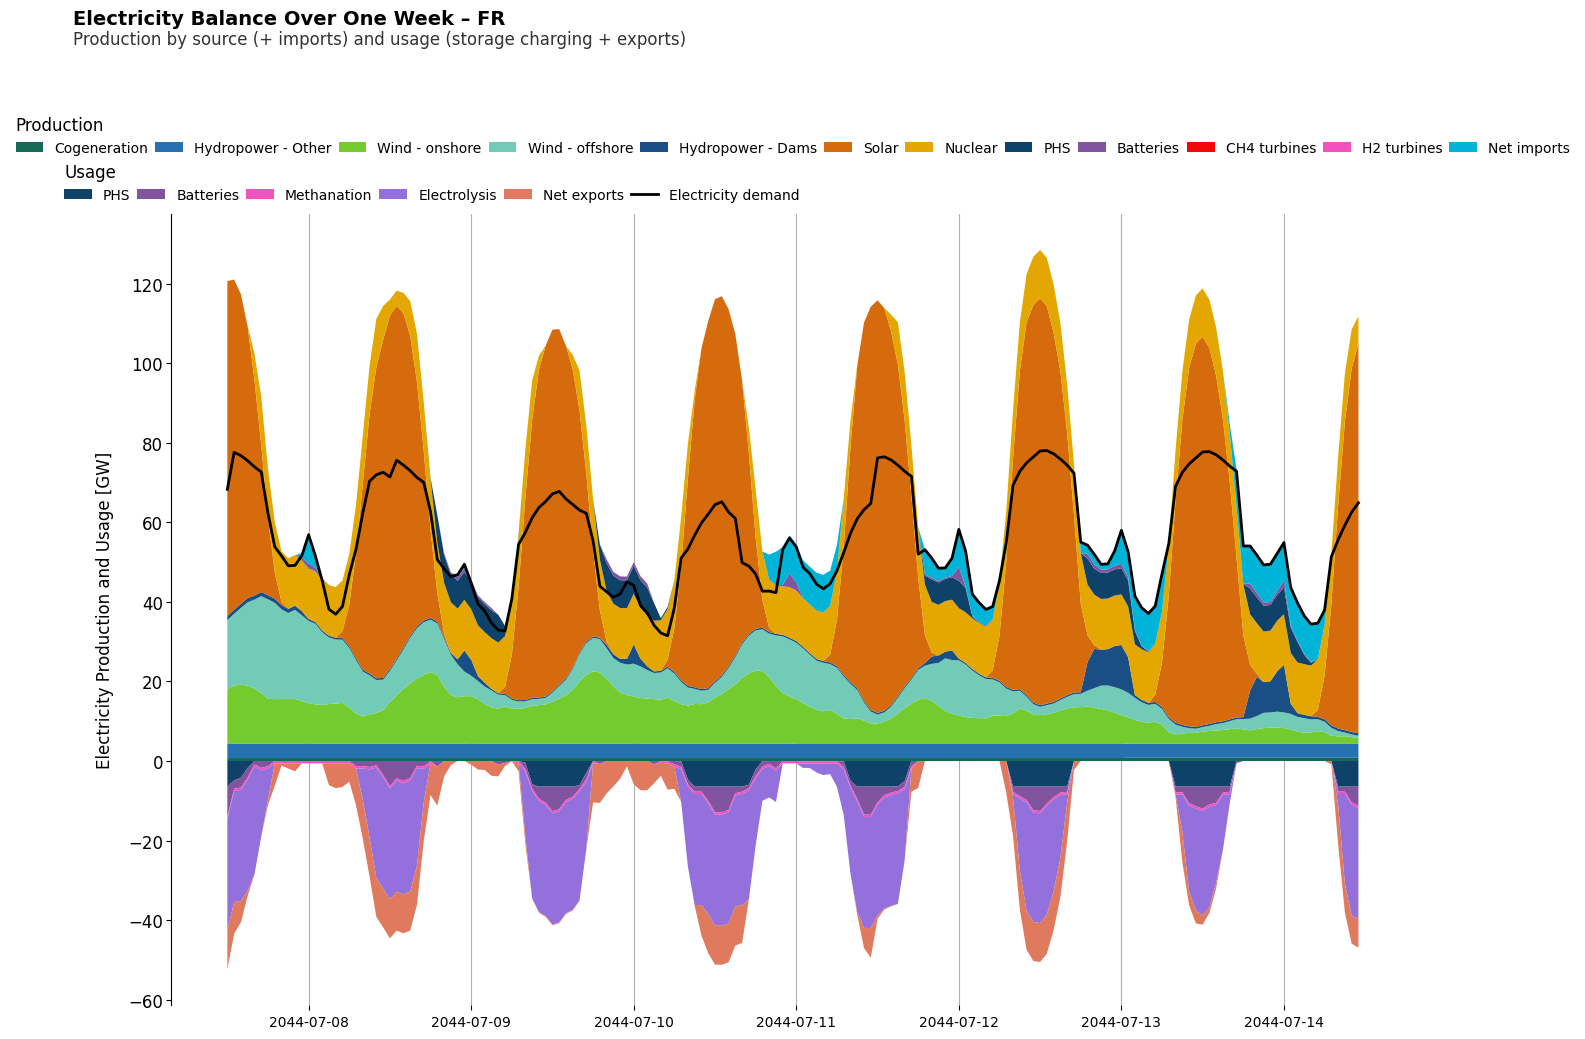

In [57]:
fig = plot_elec_balance_week(m, m.hourly_balance, m.installed_power,
                             hour=4500, area=FOCUS_AREA, lang="EN")  # summer

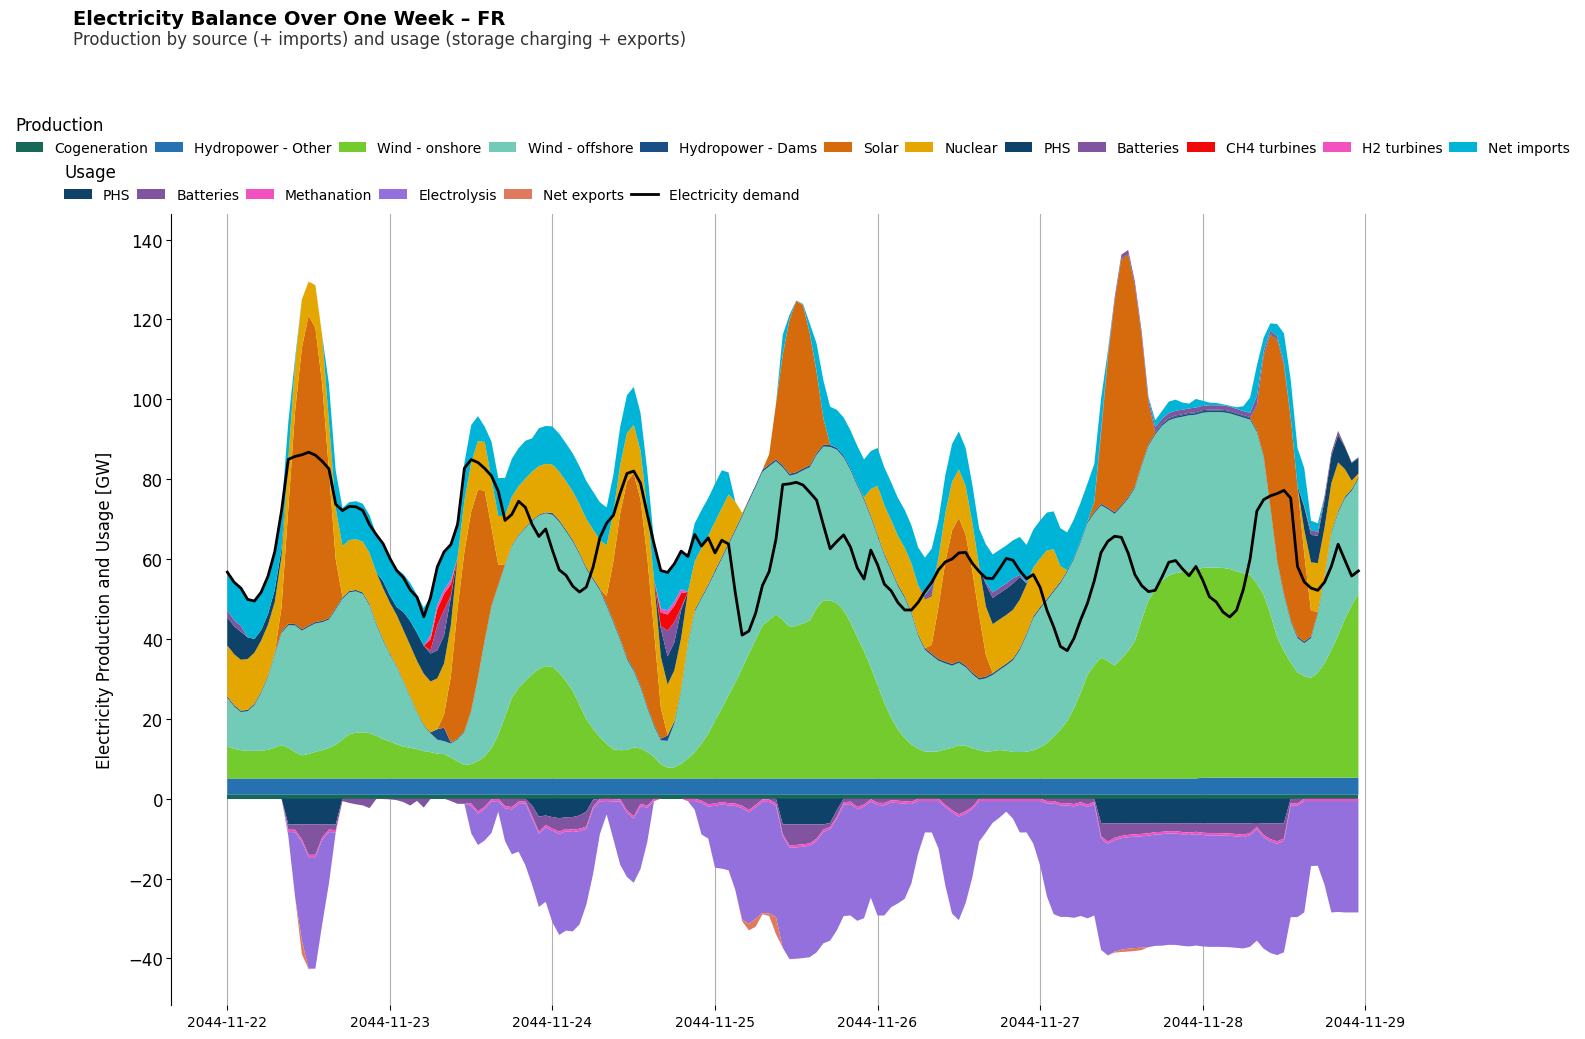

In [58]:
fig = plot_elec_balance_week(m, m.hourly_balance, m.installed_power,
                             hour=7800, area=FOCUS_AREA, lang="EN")  # autumn/winter

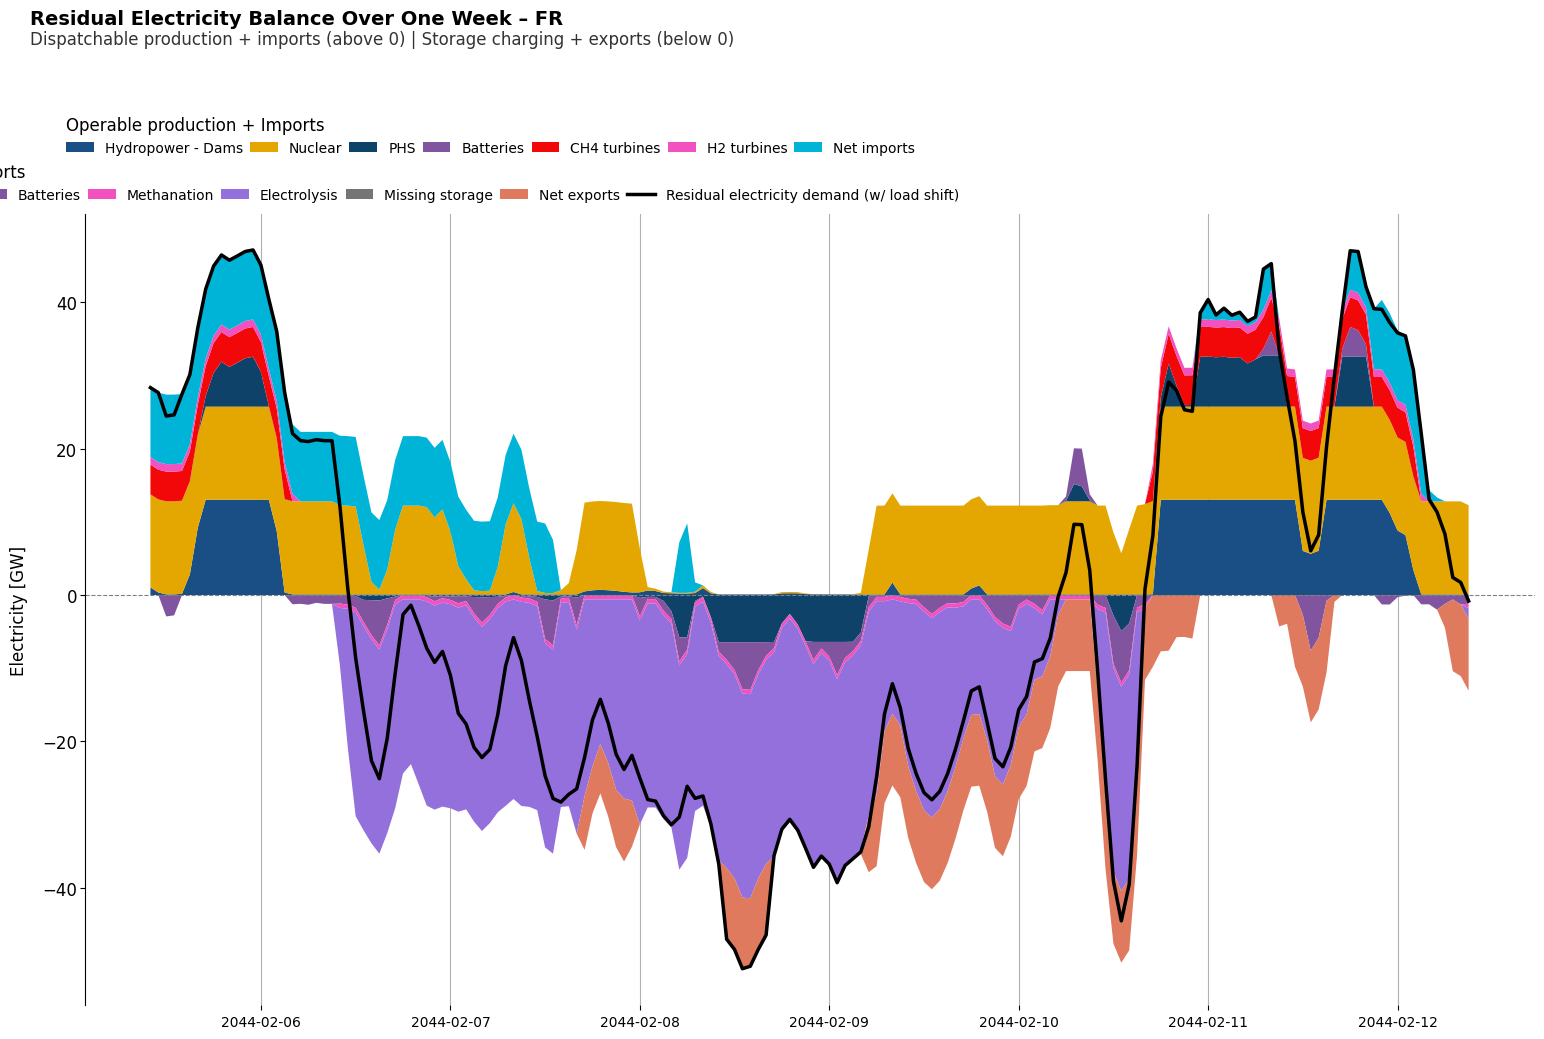

In [59]:
fig = plot_elec_residual_balance_week(m, m.hourly_balance, m.installed_power,
                                      hour=850, area=FOCUS_AREA, lang="EN")

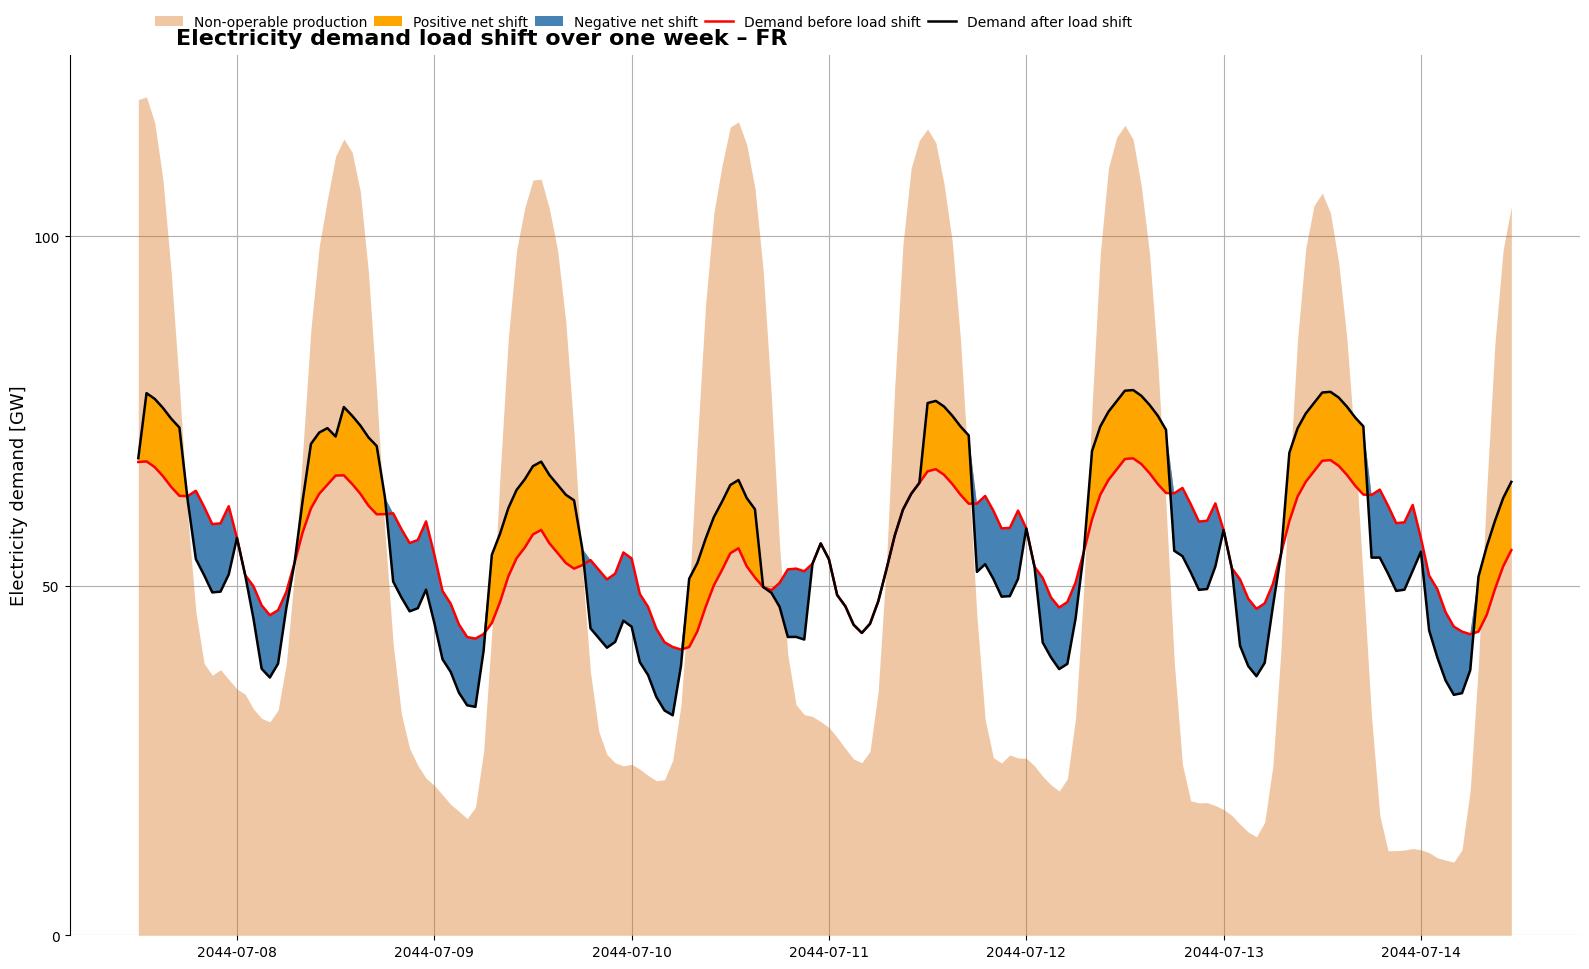

In [78]:
# DSM (load shifting) only exists for m.detailed_countries (France by default) - skip otherwise.
if FOCUS_AREA in m.detailed_countries:
    fig = plot_load_shift_week(m, m.hourly_balance, hour=4500, area=FOCUS_AREA)
else:
    print(f"No DSM for {FOCUS_AREA} (not in m.detailed_countries={m.detailed_countries})")

---
## 5. Dispatch CH4 et H2

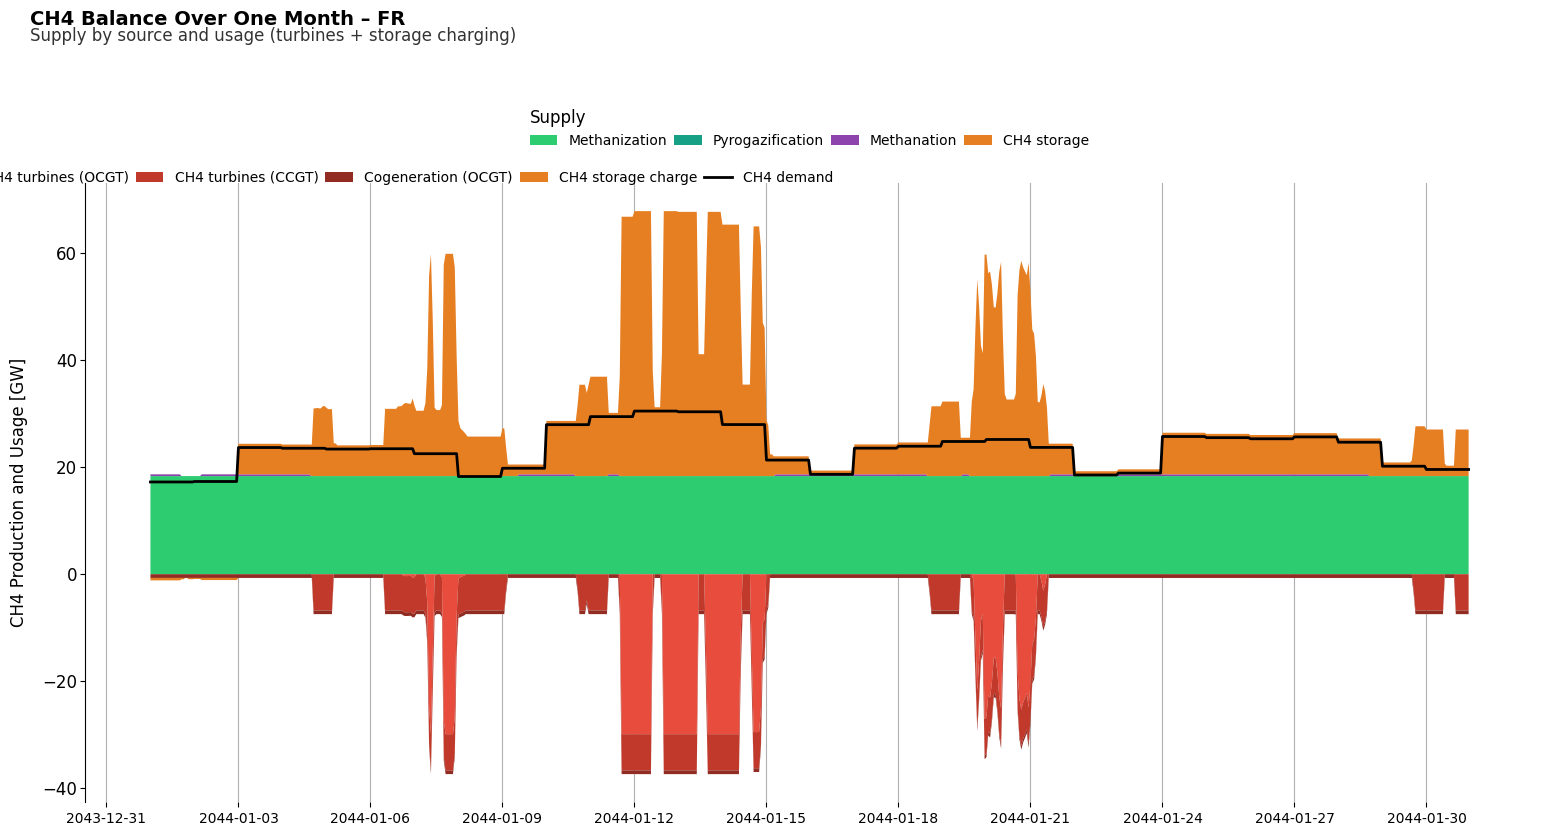

In [61]:
fig = plot_CH4_balance(m, m.hourly_balance, m.installed_power,
                       hour=0, area=FOCUS_AREA, n_hours=30*24, lang="EN")

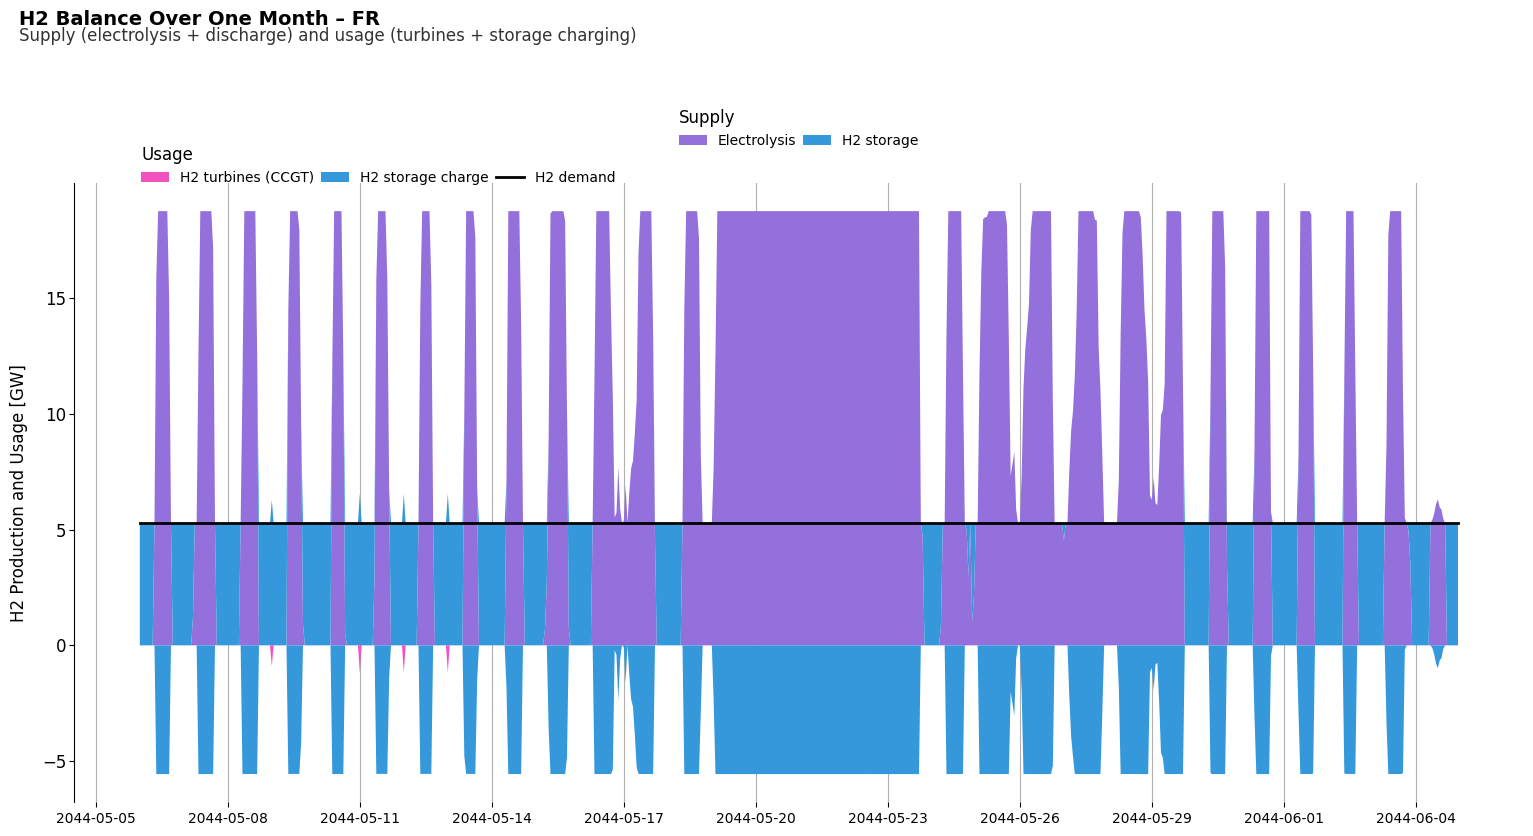

In [62]:
fig = plot_H2_balance(m, m.hourly_balance, m.installed_power,
                      hour=3000, area=FOCUS_AREA, n_hours=30*24, lang="EN")

---
## 6. Courbe de charge - demande residuelle

Demande residuelle = demande electrique - ENR variables (solaire, eolien, fil de l'eau). Le pic dimensionne le besoin en capacite pilotable ; les heures a demande residuelle negative indiquent un exces d'ENR (ecretement potentiel).

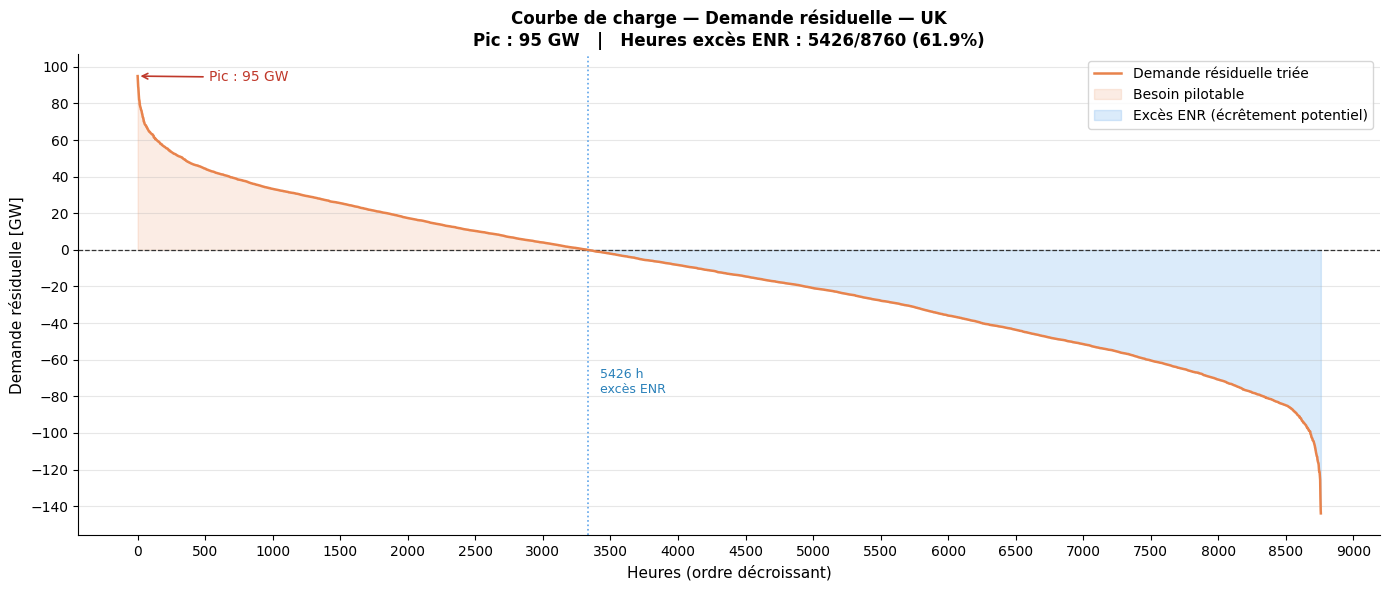


Statistiques — demande résiduelle — UK:
  peak_gw           : 94.9 GW
  peak_hour         : 955 h
  min_gw            : -143.9 GW
  hours_negative    : 5426.0 GW
  pct_negative      : 61.94 %
  mean_demand_gw    : 59.1 GW
  mean_vre_gw       : 73.9 GW
  mean_residual_gw  : -14.8 GW
  vre_coverage_pct  : 125.02 %


In [63]:
fig, stats = plot_residual_load_duration(m.hourly_balance, area="UK", lang="FR")

---
## 7. Etat des stocks sur l'annee

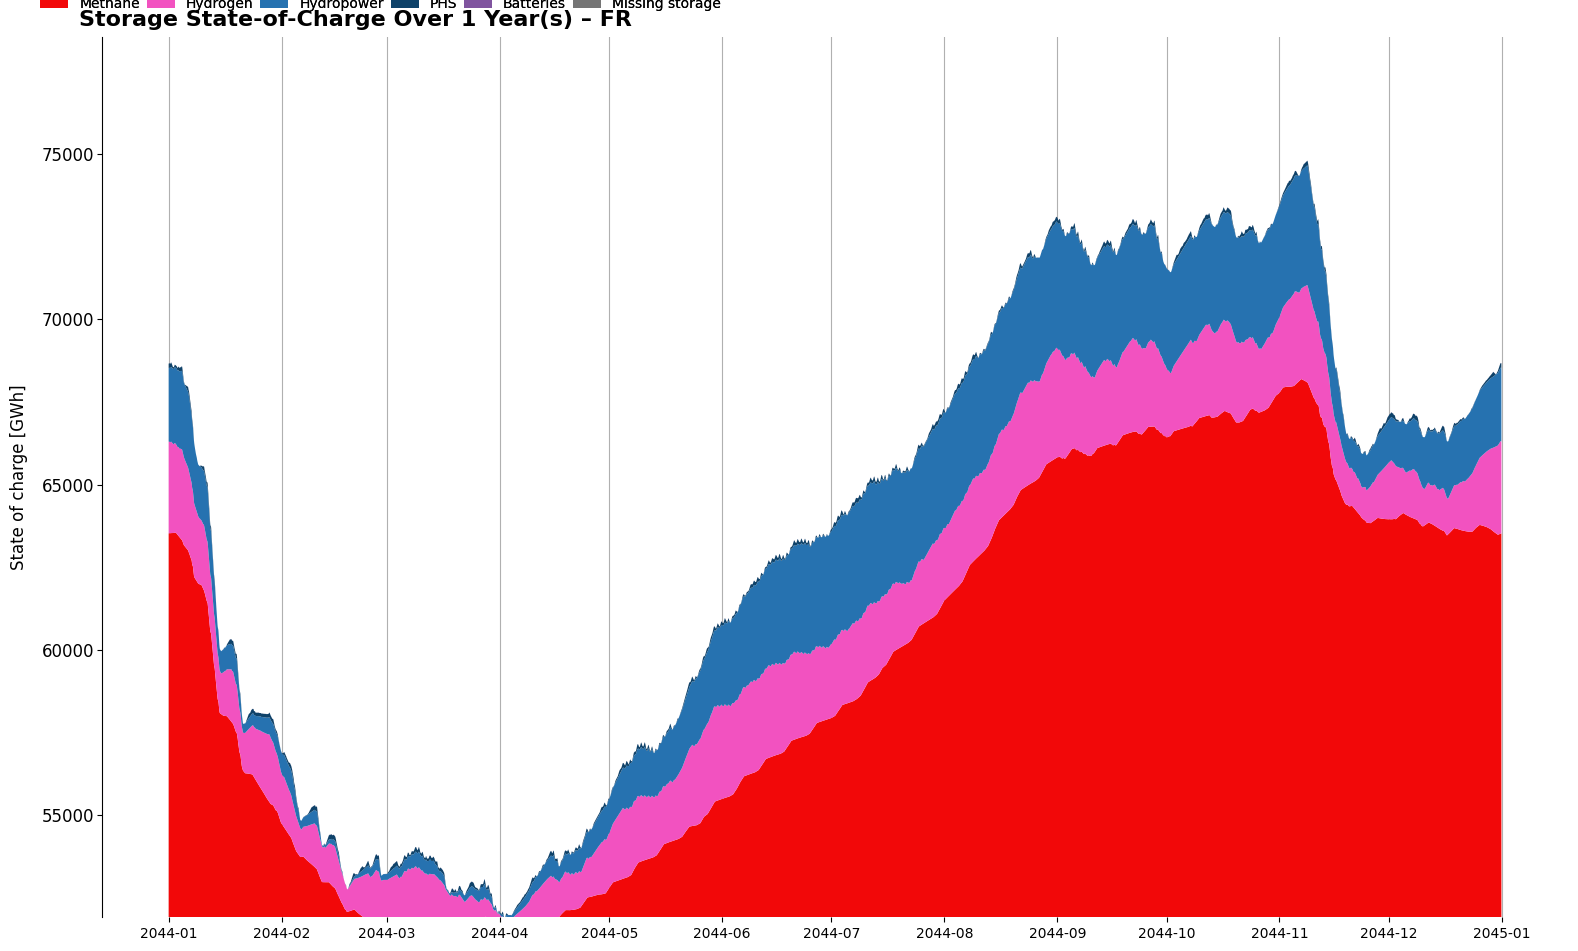

In [64]:
fig = plot_storage_state_year(m.hourly_balance, hour=0, nb_years=m.nb_years, area=FOCUS_AREA)

---
## 8. Prix spot

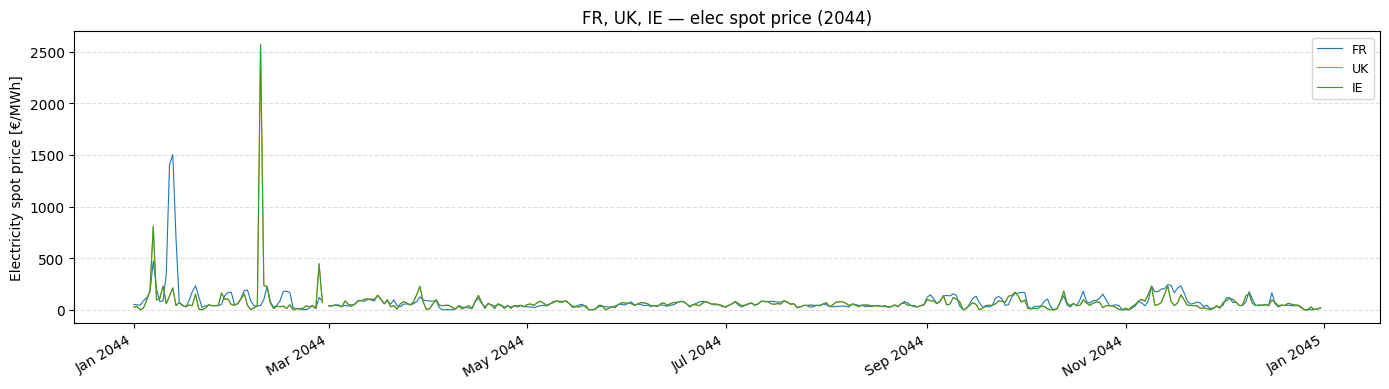

In [65]:
year_str = str(YEARS_OF_INTEREST[0])
fig, ax = plot_spot_price(m.spot_price, year_str, area=list(m.countries), granularity="d")

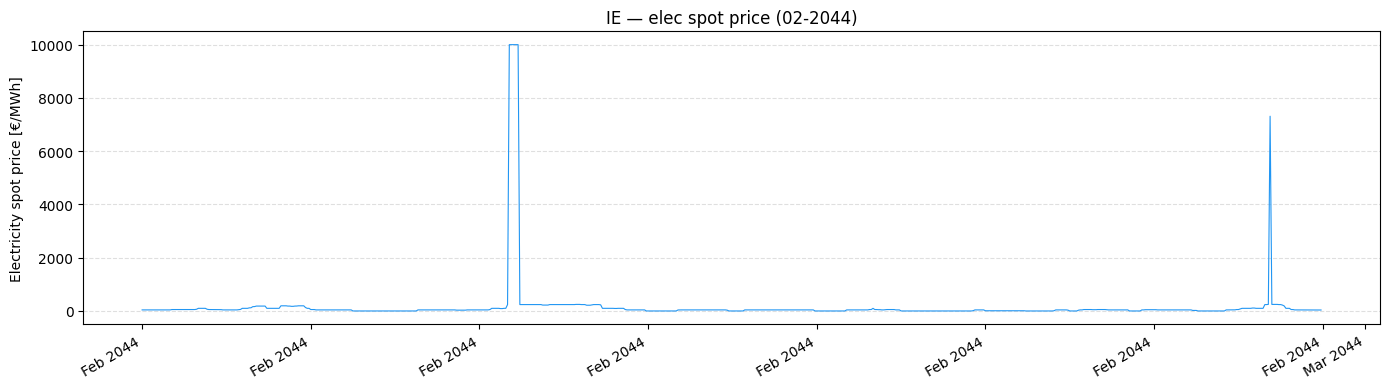

In [66]:
fig, ax = plot_spot_price(m.spot_price, f"02-{year_str}", area="IE", granularity="h")

---
## 9. Decomposition des couts

In [67]:
costs_elec, costs_CH4, costs_H2 = compute_costs(
    m.annuities, m.fOM, m.vOM, m.storage_annuities,
    m.generation_per_technology, m.installed_power, m.existing_capacity,
    m.energy_capacity, m.existing_energy_capacity, m.nb_years,
    m.elec_balance, m.str, m.CH4_balance, m.H2_balance,
)
print("Total system-wide annualised cost by vector [M-EUR/yr]:")
print(f"  elec: {float(costs_elec):.0f}   CH4: {float(costs_CH4):.0f}   H2: {float(costs_H2):.0f}")

Total system-wide annualised cost by vector [M-EUR/yr]:
  elec: 107103   CH4: 11732   H2: 5127


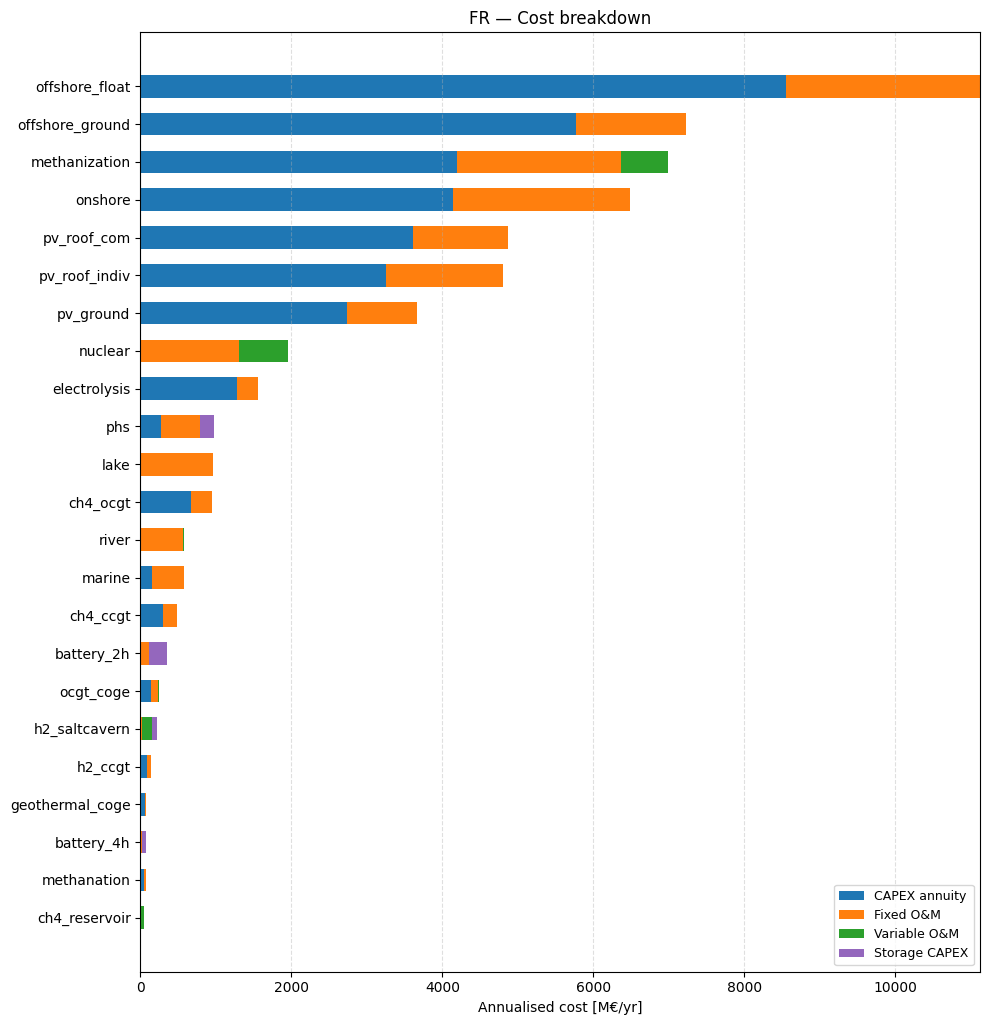

In [68]:
fig, ax = plot_cost_breakdown(
    m.installed_power, m.existing_capacity, m.energy_capacity, m.existing_energy_capacity,
    m.generation_per_technology, m.annuities, m.storage_annuities, m.fOM, m.vOM,
    area=FOCUS_AREA, nb_years=m.nb_years, lang="EN",
)

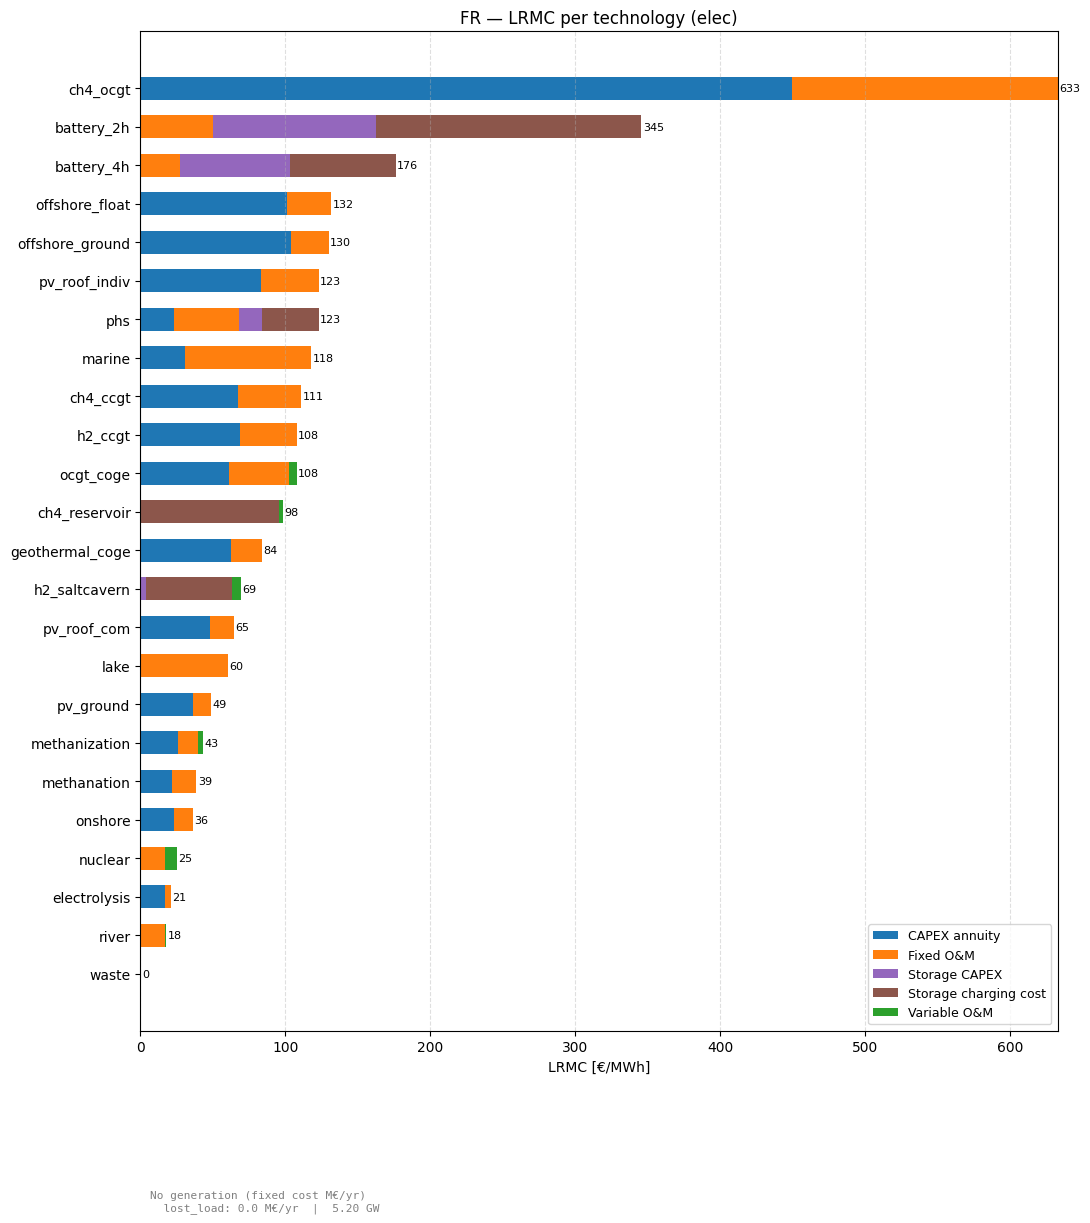

In [69]:
fig, ax = plot_cost_breakdown_per_mwh(
    m.installed_power, m.existing_capacity, m.energy_capacity, m.existing_energy_capacity,
    m.generation_per_technology, m.annuities, m.storage_annuities, m.fOM, m.vOM,
    area=FOCUS_AREA, nb_years=m.nb_years,
    hourly_balance=m.hourly_balance, spot_price=m.spot_price,
    elec_balance=m.elec_balance, CH4_balance=m.CH4_balance, H2_balance=m.H2_balance,
    lang="EN", vector="elec",
)

In [70]:
country_costs = compute_country_cost_summary(
    m.hourly_balance, m.spot_price,
    m.installed_power, m.existing_capacity, m.energy_capacity, m.existing_energy_capacity,
    m.generation_per_technology, m.annuities, m.storage_annuities, m.fOM, m.vOM,
    nb_years=m.nb_years, areas=list(m.countries),
)
country_costs

,capex_M€/yr,fOM_M€/yr,vOM_M€/yr,storage_capex_M€/yr,import_cost_M€/yr,export_revenue_M€/yr,net_cost_M€/yr
FR,35265.417359,17133.995263,1494.773083,554.880652,3911.474844,1293.613650,57066.927552
UK,46862.706985,17290.685325,451.847519,1207.571492,4693.694931,2205.369333,68301.136919
IE,13132.877066,4594.322536,230.582647,90.272491,476.187551,1931.762432,16592.479859


---
## 10. Frequentation des interconnexions

Distribution horaire du taux d'utilisation des liaisons transfrontalieres de `FOCUS_AREA` (boxplot) et repartition des heures inactives / partielles / saturees. Aucune sortie si `FOCUS_AREA` n'a pas d'interconnexion active dans ce scenario (ex: run mono-pays).

c:\Users\hadri\anaconda3\envs\env_EOLES_CIRED\Lib\site-packages\linopy\common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


,cap_gw,mean_util_%,mean_flow_gw,% h saturated,% h idle,energy_TWh
interco,,,,,,
FR→UK,9.8,35.2,3.45,25.1,52.3,30.19
UK→FR,9.5,43.0,4.08,32.8,47.2,35.74


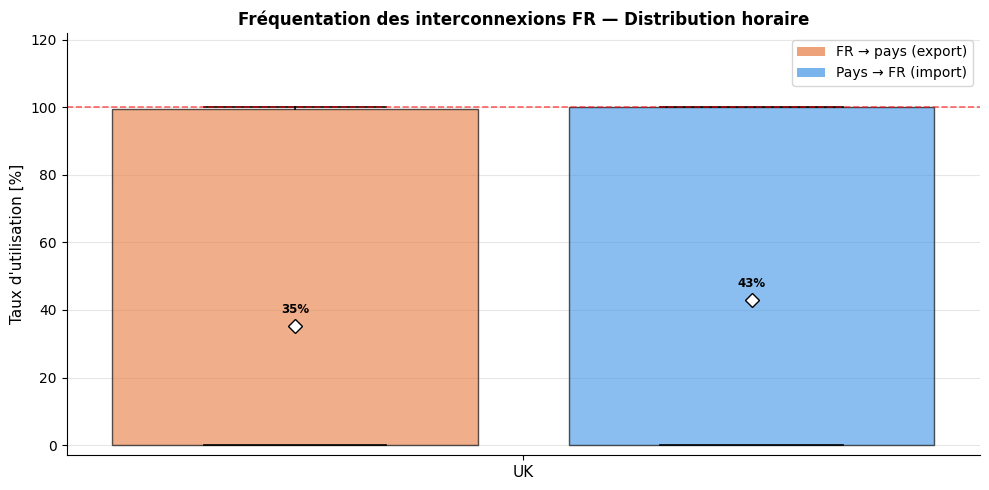

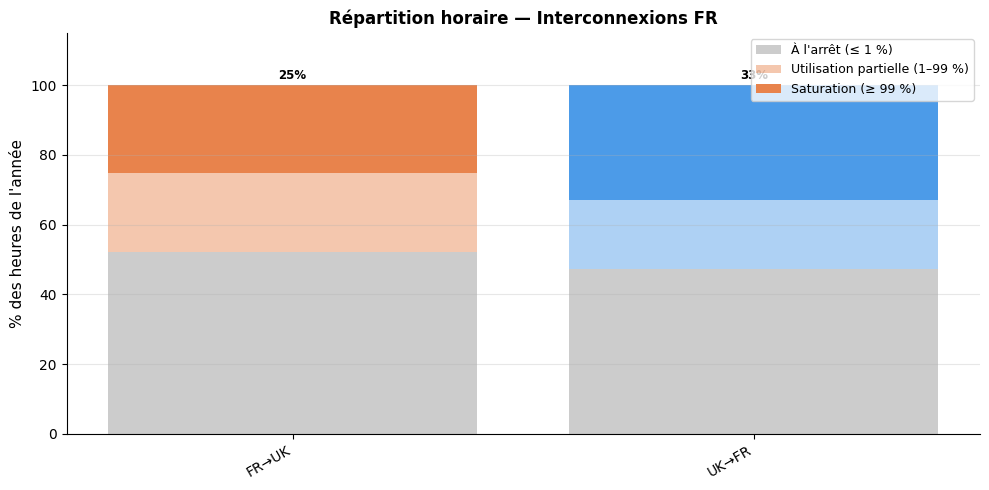

In [71]:
links = pd.read_csv("inputs/area_indexed/links.csv", index_col=0)
fig1, fig2, interco_summary = plot_interconnection_utilization(
    m.model.solution, links, area=FOCUS_AREA, lang="FR",
)
interco_summary

---
## 11. Variables duales - capacite maximale

Valeur marginale (M-EUR/GW/an) de la contrainte de capacite maximale par technologie, pour `FOCUS_AREA`. Un dual non nul (negatif) indique une contrainte active : le modele investirait davantage dans cette technologie si le plafond etait releve.

In [72]:
duals = m.model.constraints.max_capacity_prod.dual.to_dataframe().dropna()
duals.loc[FOCUS_AREA] if FOCUS_AREA in duals.index.get_level_values(0) else duals

,dual
tech,
offshore_float,-0.000000
offshore_ground,-0.000000
onshore,-23.232649
pv_ground,-0.000000
pv_roof_com,-0.000000
pv_roof_indiv,-0.000000
river,-170.657346
lake,-0.000000
nuclear,-0.000000


---
## 12. Dual vs. profit : les technos contraintes en capacite degagent-elles un profit ?

Intuition a verifier : une techno dont la contrainte de capacite maximale est active (dual non nul) devrait afficher un profit positif (rente de rarete) - sans le plafond, le modele investirait davantage jusqu'a ramener le profit vers 0. `extract_capacity_duals` combine les duals des trois contraintes de capacite max (prod/conversion/stockage, categories disjointes) en un seul tableau ; `plot_dual_vs_profit` les affiche cote a cote avec `m.profits`, en mettant en gras les technos dont la contrainte est active.

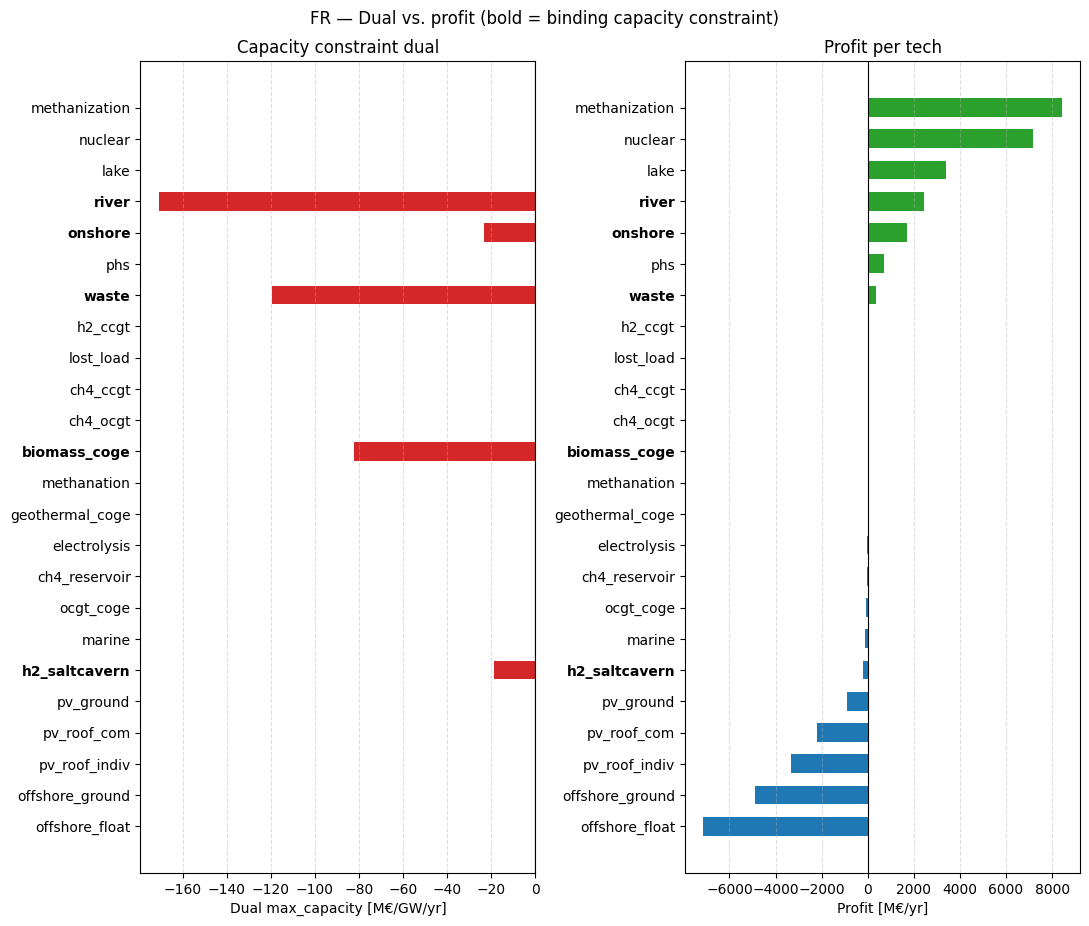

In [73]:
capacity_duals = extract_capacity_duals(m.model)
fig, axes = plot_dual_vs_profit(capacity_duals, m.profits, area=FOCUS_AREA, lang="EN")

Verification numerique de la relation de dualite LP derriere le graphique ci-dessus : a l'optimum, pour chaque techno soumise a une contrainte de capacite max,

`profit = (annuite + fOM) * capacite_existante  -  dual * capacite_totale`

(la rente degagee par une capacite deja amortie, plus la rente de raret sur la capacite totale si la contrainte est active). Un residu non nul peut venir (i) du stockage, dont le profit nette aussi l'annuite de capacite *energie* (non couverte par ces duals de capacite *puissance*), ou (ii) du bruit numerique du solveur barrier sans crossover.

In [79]:
import importlib, utils_results
importlib.reload(utils_results)
from utils_results import extract_spot_price, extract_profit, extract_capacity_duals, check_profit_dual_consistency

# 1. Recalcule spot_price (frr *10, sans négation)
m.spot_price = extract_spot_price(m.model, year_coords=m.year)

# 2. Recalcule profits avec le fix _hb (coordonnées tech correctement alignées)
m.profits = extract_profit(
    m.hourly_balance, m.spot_price, m.vOM,
    m.new_capacity_annualized_costs, m.new_energy_capacity_annualized_costs,
    m.frr_requirements, m.fcr_requirement, m.reserve_activation_rate, m.conversion_efficiency,
    m.installed_power,
    m.all_tech, m.elec_balance, m.str, m.from_CH4_to_elec, m.from_H2_to_elec, m.reserve, m.vre,
    m.CH4_balance, m.H2_balance, m.from_elec_to_CH4, m.from_elec_to_H2,
)

# 3. capacity_duals (inchangé, mais recalculé par cohérence)
capacity_duals = extract_capacity_duals(m.model)

# 4. Table complète de cohérence
consistency = check_profit_dual_consistency(
    m.profits, capacity_duals, m.installed_power, m.existing_capacity,
    m.annuities, m.fOM, area="UK",
)
print(f"{consistency['consistent'].sum()}/{len(consistency)} technos cohérentes")
consistency.sort_values("residual_M€/yr", key=abs, ascending=False)


9/35 technos cohérentes


,profit_M€/yr,predicted_M€/yr,residual_M€/yr,consistent
tech,,,,
offshore_float,-14703.809819,0.000000,-14703.809819,False
offshore_ground,-8681.442199,0.000000,-8681.442199,False
pv_roof_indiv,-2351.439504,0.000000,-2351.439504,False
pv_roof_com,-1888.687942,0.000000,-1888.687942,False
pv_ground,-786.258431,0.000000,-786.258431,False
ocgt_coge,-226.480541,0.000000,-226.480541,False
river,243.729294,336.048724,-92.319431,False
phs,548.454414,600.947101,-52.492687,False
biomass_coge,-15.056273,0.000000,-15.056273,False
